In [19]:
import uproot
import awkward as ak
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import hist
import vector
print("uproot version",uproot.__version__)
print("awkward version",ak.__version__)
print("numpy version",np.__version__)
print("matplotlib version",matplotlib.__version__)
print("hist version",hist.__version__)
print("vector version",vector.__version__)
from scipy.optimize import curve_fit
from scipy.special import erf 

vector.register_awkward() 

import os

uproot version 5.5.1
awkward version 2.7.2
numpy version 2.1.3
matplotlib version 3.9.0
hist version 2.8.0
vector version 1.5.2


In [20]:
def crystal_ball(x, N, mu, sigma, alpha, n):
    t = (x - mu) / sigma
    A = (n / abs(alpha))**n * np.exp(-alpha**2 / 2)
    B = n / abs(alpha) - abs(alpha)
    C = (n / abs(alpha)) / (n - 1) * np.exp(-alpha**2 / 2)
    D = np.sqrt(np.pi / 2) * (1 + erf(abs(alpha) / np.sqrt(2)))
    norm = sigma * (C + D)
    result = np.piecewise(
        t,
        [t > -alpha, t <= -alpha],
        [lambda t: N * np.exp(-t**2 / 2) / norm,
         lambda t: N * A * (B - t)**(-n) / norm]
    )
    return result

Traitement du fichier : run292140.mc.root
nMuonsGen =  14000
nMuons =  7742


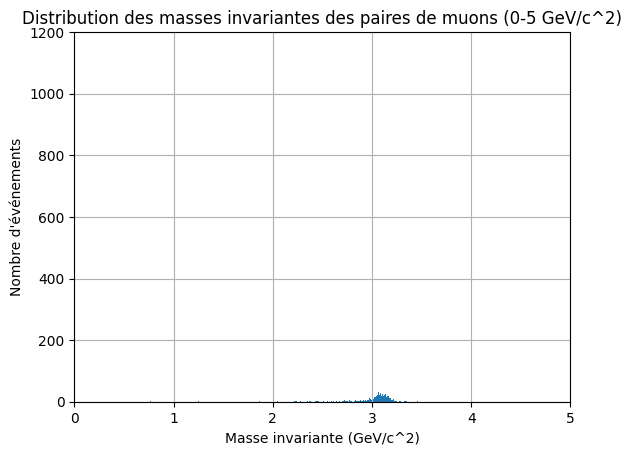

943
943
Paramètres CB2 : [9.53446446 3.09930283 0.0623411  1.00100816 2.20667129]


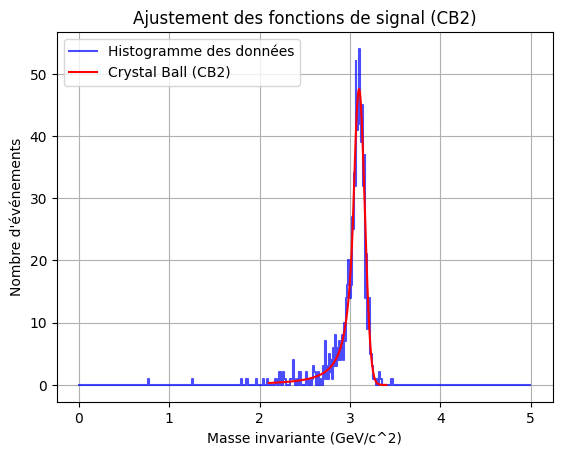

Traitement du fichier : run290721.mc.root
nMuonsGen =  40000
nMuons =  21341


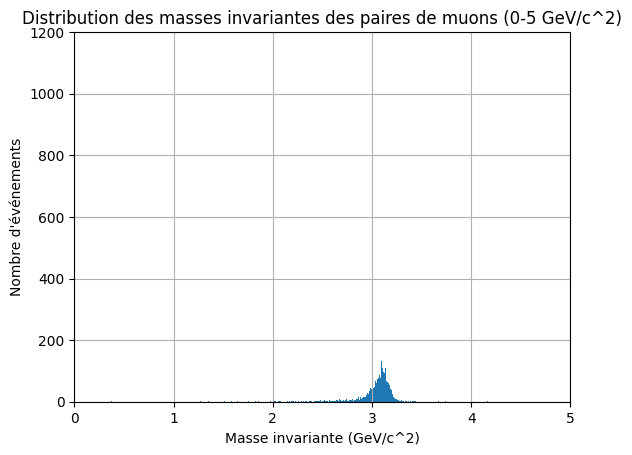

2546
2546
Paramètres CB2 : [24.38731459  3.10644904  0.05771392  0.64911     8.96309202]


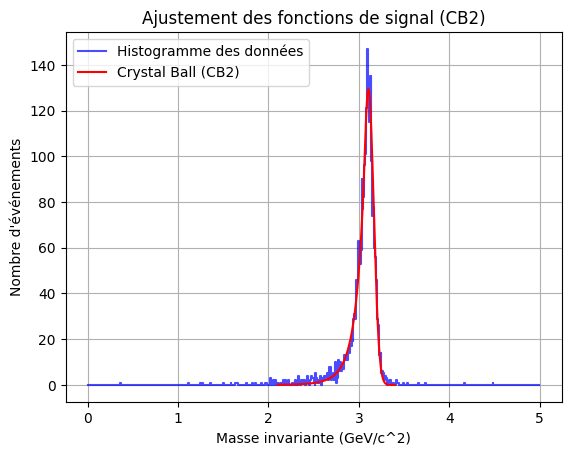

Traitement du fichier : run292160.mc.root
nMuonsGen =  260000
nMuons =  143259


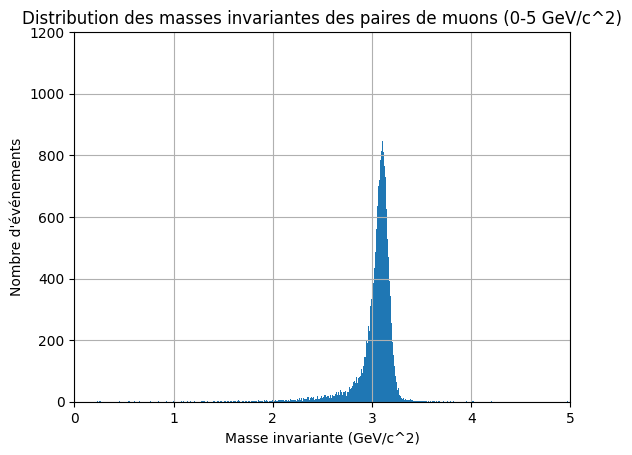

17549
17549
Paramètres CB2 : [1.72473250e+02 3.10095427e+00 6.29294456e-02 8.73545084e-01
 3.40483785e+00]


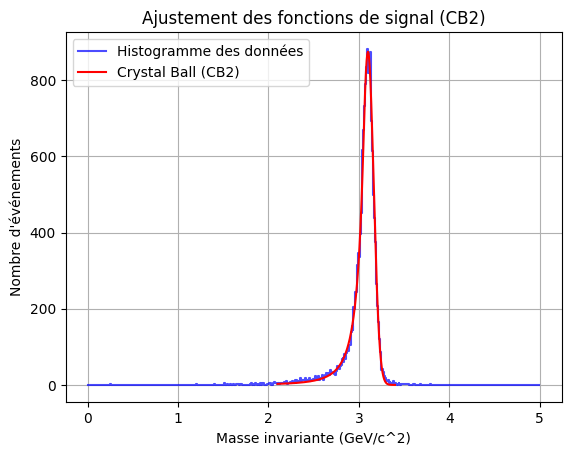

Traitement du fichier : run291976.mc.root
nMuonsGen =  140000
nMuons =  77005


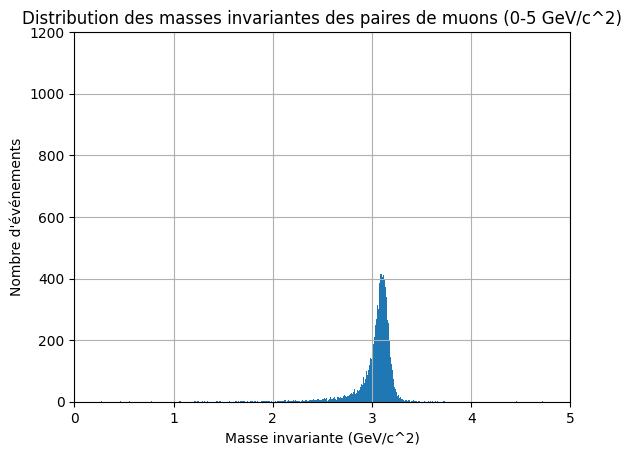

9322
9322
Paramètres CB2 : [9.17318549e+01 3.10388173e+00 6.07272065e-02 8.15420332e-01
 3.51480524e+00]


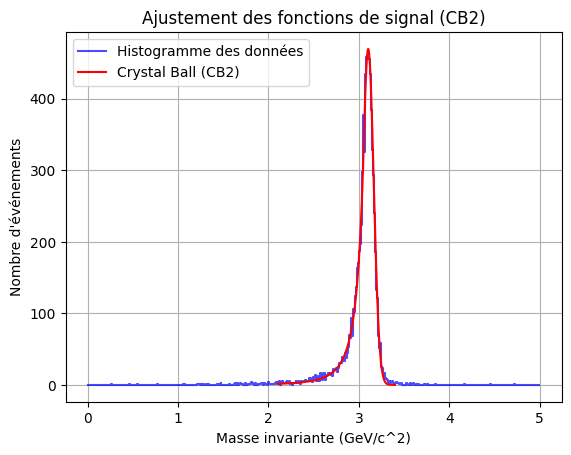

Traitement du fichier : run291944.mc.root
nMuonsGen =  100000
nMuons =  55365


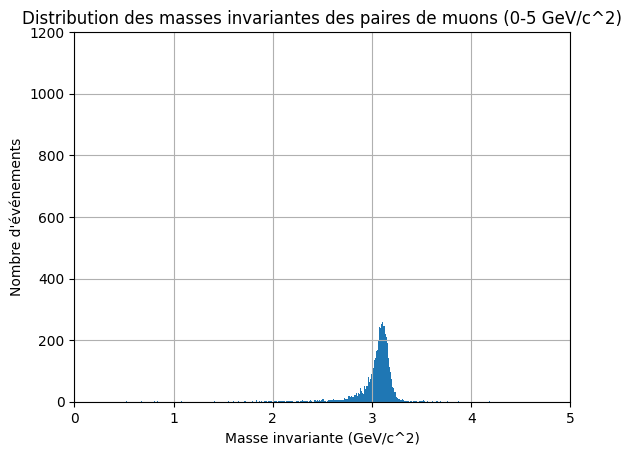

6860
6860
Paramètres CB2 : [6.73492639e+01 3.10337061e+00 6.11597860e-02 8.12024963e-01
 3.73230338e+00]


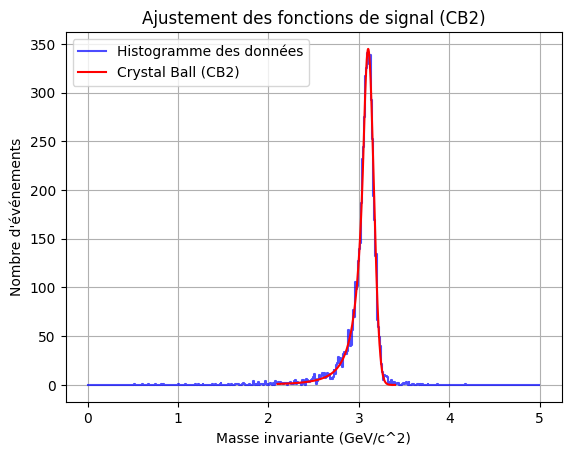

Traitement du fichier : run291942.mc.root
nMuonsGen =  60000
nMuons =  33146


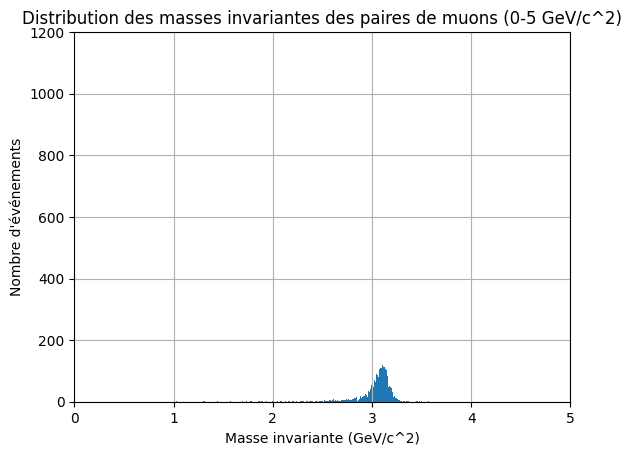

4129
4129
Paramètres CB2 : [39.80635185  3.10370516  0.06149842  0.74531022  5.57532411]


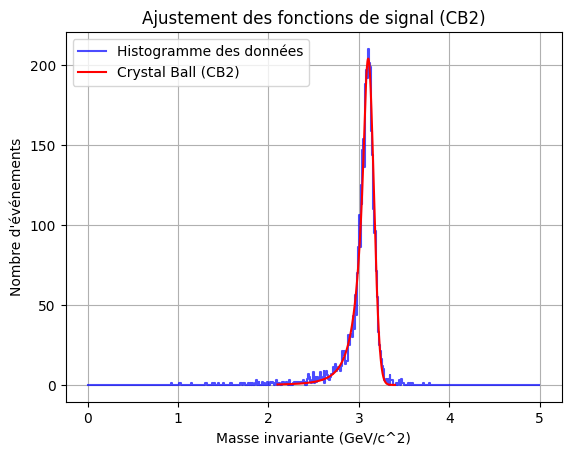

Traitement du fichier : run292062.mc.root
nMuonsGen =  240000
nMuons =  131802


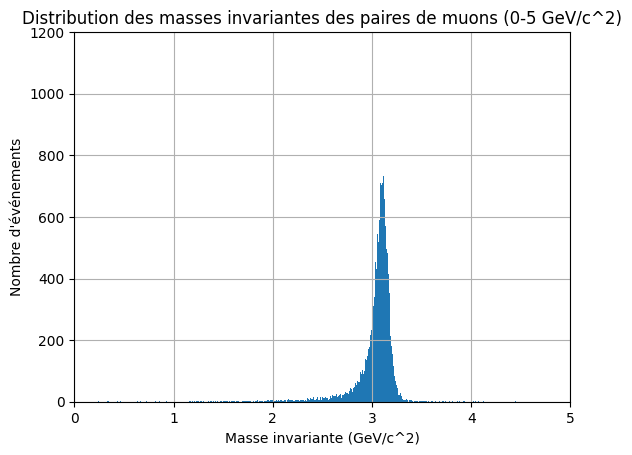

16296
16296
Paramètres CB2 : [1.58906805e+02 3.10298444e+00 5.98022753e-02 8.18317982e-01
 3.72585348e+00]


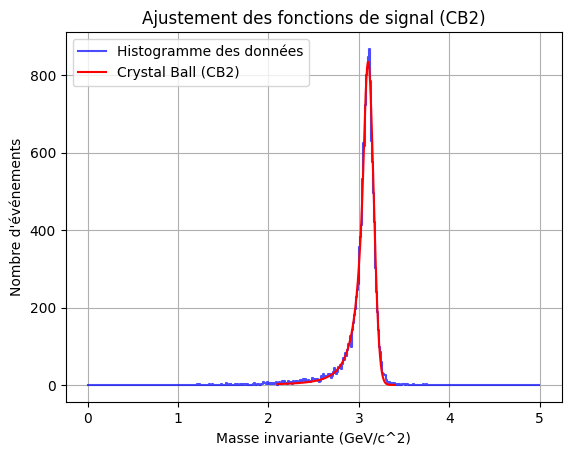

Traitement du fichier : run291692.mc.root
nMuonsGen =  80000
nMuons =  44194


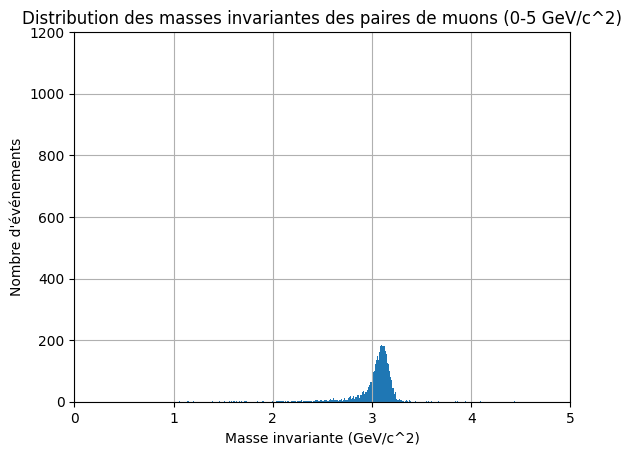

5617
5617
Paramètres CB2 : [56.05235337  3.10252725  0.06346143  0.92701623  2.69422725]


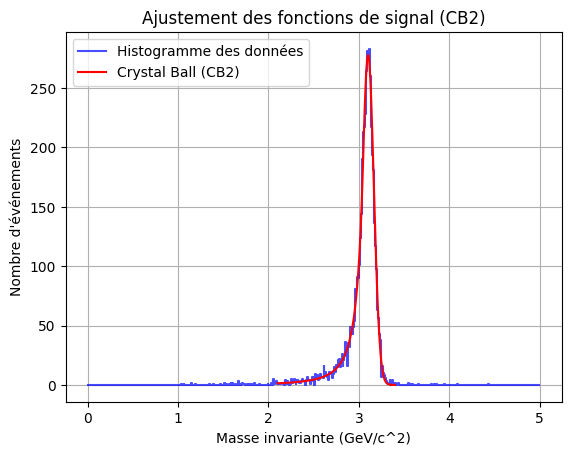

Traitement du fichier : run291283.mc.root
nMuonsGen =  80000
nMuons =  46241


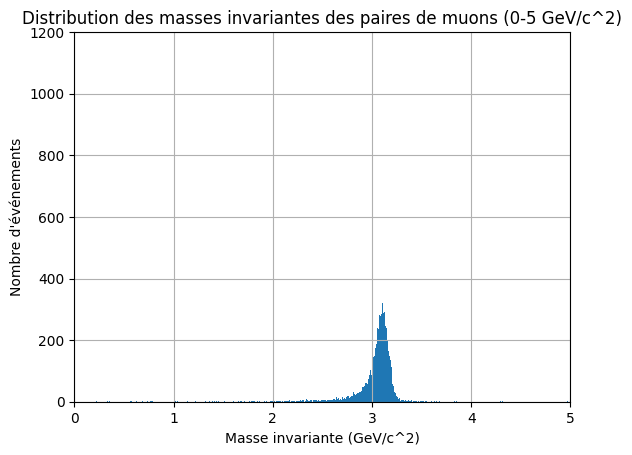

6229
6229
Paramètres CB2 : [6.06839422e+01 3.10318386e+00 6.00723946e-02 7.70165198e-01
 4.14742700e+00]


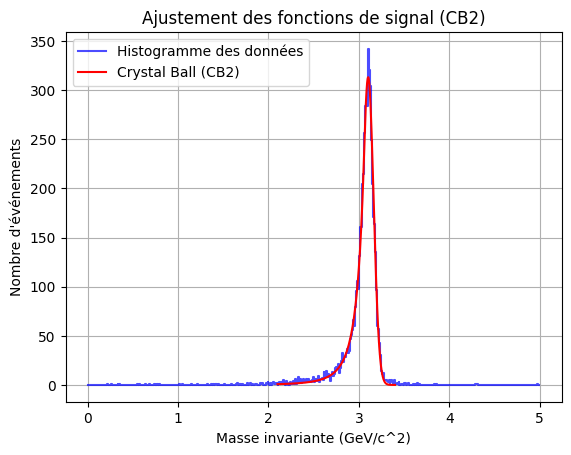

Traitement du fichier : run292164.mc.root
nMuonsGen =  16000
nMuons =  8771


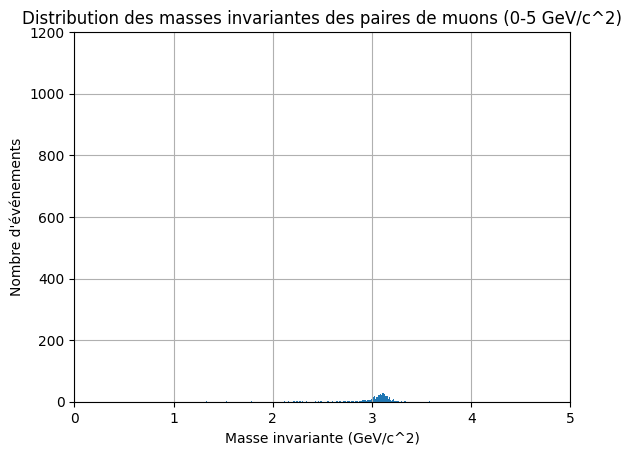

1084
1084
Paramètres CB2 : [10.52235314  3.10319424  0.05834739  0.88345917  3.15700555]


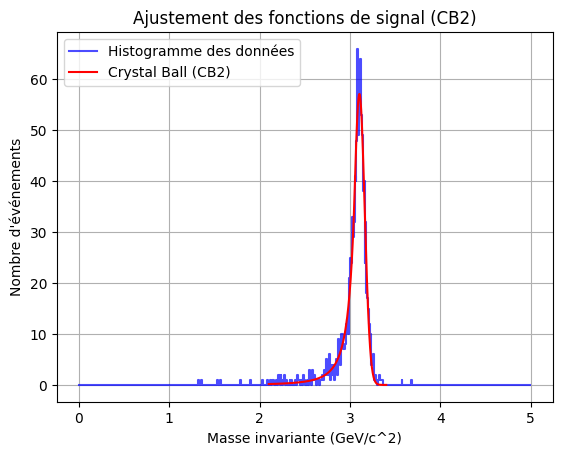

Limite de fichiers atteinte.


In [23]:
folder_path = "/pbs/throng/training/nantes-m2-rps-exp/data"
results = []
j_psi_gen = []
j_psi_rec = []

file_count =0

for file_name in os.listdir(folder_path):
    if file_name.endswith(".mc.root"):
        file_path = os.path.join(folder_path, file_name)
        results.append(file_name[0:-8])

        print(f"Traitement du fichier : {file_name}")
        file = uproot.open(file_path)

        gen = file["genTree"]
        m = gen.arrays(["nMuonsGen","Muon_GenPx","Muon_GenPy","Muon_GenPz","Muon_GenE","Muon_GenLabel","Muon_GenMotherPDGCode"])
        
        nMuonsGen = 0
        for i in range(len(m)):
            info = m[i]["nMuonsGen"]
            nMuonsGen += info
        print("nMuonsGen = ", nMuonsGen)

        events = file["eventsTree"]
        n = events.arrays(["zVtx","isCMUL","nMuons","Muon_Px","Muon_Py","Muon_Pz","Muon_E","Muon_Charge","Muon_thetaAbs","Muon_matchedTrgThreshold","Muon_MCLabel"])

        nMuons = 0
        for i in range(len(n)):
            info = n[i]["nMuons"]
            nMuons += info
        print("nMuons = ", nMuons)

        
        #Coupure

        mask = (n["nMuons"] >= 2) & ak.all(m["Muon_GenMotherPDGCode"] == 443, axis=1) 
        
        # filtered_443 = n[ak.all(m["Muon_GenMotherPDGCode"] == 443, axis=1)]
        # print(f"apres 443 = ", len(filtered_443))
        # filtered_443_2muons = n[mask]
        # print(f"apres 443, 2muon = ", len(filtered_443_2muons))
        # filtered_443_2muons_isCMUL = n[mask & (n.isCMUL)]
        # print(f"apres 443, 2muon, isCMUL  = ", len(filtered_443_2muons_isCMUL))
        # filtered_443_2muons_isCMUL_zVtx = n[mask & (n.isCMUL) & (abs(n.zVtx)<10)]
        # print(f"apres 443, 2muon, isCMUL, zvtx = ", len(filtered_443_2muons_isCMUL_zVtx))

        
        
        # mask = (n["nMuons"] >= 2) & ak.all(m["Muon_GenMotherPDGCode"] == 443, axis=1)
        # filtered_gen_events = m[ak.all(m["Muon_GenMotherPDGCode"] == 443, axis=1)]
        # filtered_events = n[mask & (n.isCMUL)&(abs(n.zVtx)<10)]
        # print(len(filtered_gen_events))
        # print(len(filtered_events))
        # j_psi_gen.append(len(filtered_gen_events))
        # j_psi_rec.append(len(filtered_events))



        #--------------------------Figure-------------------------------

        filtered_events = n[mask & (n.isCMUL)&(abs(n.zVtx)<10)]

        muon_vectors = ak.zip({
            "px": filtered_events.Muon_Px,
            "py": filtered_events.Muon_Py,
            "pz": filtered_events.Muon_Pz,
            "E": filtered_events.Muon_E
        }, with_name="Momentum4D")
        
        # Calculer les masses invariantes pour chaque paire de muons dans chaque événement
        invariant_masses = ak.combinations(muon_vectors, 2, fields=["muon1", "muon2"])
        masses = (invariant_masses.muon1 + invariant_masses.muon2).mass
        
        # Créer un histogramme des valeurs de la masse
        flattened_masses = ak.flatten(masses)  # Aplatir les données pour l'histogramme
        filtered_masses = flattened_masses[(flattened_masses >= 0) & (flattened_masses <= 5)]  # Filtrer les masses entre 0 et 10
        
        
        hist, bin_edges = np.histogram(flattened_masses, bins=500, range=(0, 5))
        plt.hist(filtered_masses, bins=500)
            
        plt.xlabel('Masse invariante (GeV/c^2)')
        plt.ylabel("Nombre d'événements")
        plt.xlim(0,5)
        plt.ylim(0,1200)
        #plt.yscale('log')
        plt.title('Distribution des masses invariantes des paires de muons (0-5 GeV/c^2)')
        plt.grid(True)
        plt.show()
        
        print(len(masses)) #nb j/psi
        print(len(filtered_events)) 



        #--------------------------------Fit-----------------------------

        bin_centers = np.asarray((bin_edges[:-1] + bin_edges[1:]) / 2)
        y_data = np.asarray(hist)
        valid_indices = (bin_centers >= 2.1) & (bin_centers <= 3.4)
        x_peak = bin_centers[valid_indices]
        y_peak = y_data[valid_indices]
        
        
        try:
            popt_cb2, pcov_cb2 = curve_fit(
                crystal_ball, x_peak, y_peak,
                p0=[np.max(y_peak), 3.0, 0.1, 1.5, 5],
                bounds=([0, 2.1, 0.01, 0.1, 1], [np.inf, 3.4, 1, 5, 10]),
                maxfev=200000
            )
        except RuntimeError as e:
            print("Erreur d'ajustement Crystal Ball :", e)
        
        # Générer les courbes ajustées
        x_fit = np.linspace(2.1, 3.4, 1000)
        y_cb2 = crystal_ball(x_fit, *popt_cb2) if 'popt_cb2' in locals() else None
        
        # Résultats de l'ajustement
        if 'popt_cb2' in locals():
            print(f"Paramètres CB2 : {popt_cb2}")
        
        # Tracer les données et les ajustements
        plt.step(bin_centers, y_data, where='mid', label='Histogramme des données', color='blue', alpha=0.7)
        if y_cb2 is not None:
            plt.plot(x_fit, y_cb2, label='Crystal Ball (CB2)', color='red')
        
        # Mise en forme
        plt.xlabel('Masse invariante (GeV/c^2)')
        plt.ylabel('Nombre d\'événements')
        plt.title('Ajustement des fonctions de signal (CB2)')
        plt.legend()
        plt.grid(True)
        plt.show()

      

        #-------------------------------------Pour n fichier seulement---------a supprimer plus tard (supprimer l'affichage surtout)--------------------
        
        file_count += 1
        if file_count >= 10 :
            print("Limite de fichiers atteinte.")
            break